# Music segmentation preprocessing test notebook

This notebook exercises:
- wav -> mel spectrogram
- mel normalization
- mel denormalization
- mel -> wav reconstruction
- stem.mp4 -> 5 wav files


In [1]:
from pathlib import Path
import sys
import torch
import torchaudio

PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from processing.audio_transforms import (
    MelSpecConfig,
    WavToMelSpectrogram,
    MelSpectrogramNormalizer,
    MelSpectrogramDenormalizer,
    MelSpectrogramToWav,
    load_audio,
    save_audio,
)
from dataset.video_stems import split_stem_video_to_wavs


In [2]:
config = MelSpecConfig(sample_rate=44100, n_fft=2048, hop_length=512, n_mels=128, top_db=80.0)
wav_to_mel = WavToMelSpectrogram(config)
normalizer = MelSpectrogramNormalizer(min_db=-80.0, max_db=0.0)
denormalizer = MelSpectrogramDenormalizer(min_db=-80.0, max_db=0.0)
mel_to_wav = MelSpectrogramToWav(config, n_iter=64)


## Test wav -> mel -> normalized mel -> wav
Set `INPUT_WAV` to one MUSDB18 stem or mixture wav path.

In [5]:
INPUT_WAV = Path('example.wav')
OUTPUT_DIR = Path('notebook_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

wav, sr = load_audio(INPUT_WAV, target_sr=config.sample_rate, mono=False)
mel_db = wav_to_mel(wav)
mel_norm = normalizer(mel_db)
mel_restored = denormalizer(mel_norm)
mel_to_wav = MelSpectrogramToWav(config, n_iter=64, length=wav.shape[-1])
wav_recon = mel_to_wav(mel_restored)
save_audio(OUTPUT_DIR / 'reconstructed.wav', wav_recon, config.sample_rate)

print('wav shape:', tuple(wav.shape))
print('mel_db shape:', tuple(mel_db.shape))
print('mel_norm min/max:', float(mel_norm.min()), float(mel_norm.max()))
print('recon shape:', tuple(wav_recon.shape))


wav shape: (2, 9256960)
mel_db shape: (2, 128, 18081)
mel_norm min/max: 0.5769988298416138 1.0
recon shape: (2, 9256960)


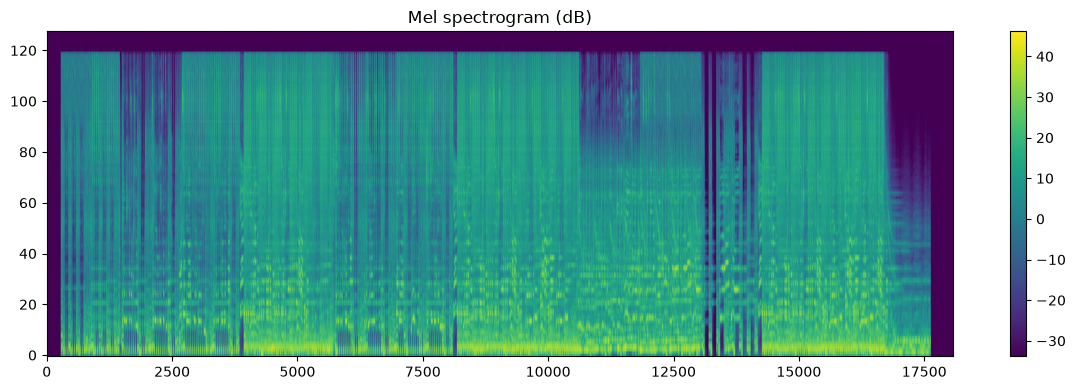

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.imshow(mel_db[0].cpu(), origin='lower', aspect='auto')
plt.title('Mel spectrogram (dB)')
plt.colorbar()
plt.tight_layout()
plt.show()


## Test mp4 stems -> 5 wav files
Use this only if your mp4 contains at least 5 audio streams.

In [8]:
INPUT_MP4 = Path('stem.mp4')
STEM_OUTPUT_DIR = Path('stem_wavs')
stem_paths = split_stem_video_to_wavs(INPUT_MP4, STEM_OUTPUT_DIR, stem_names=['mixture', 'drums', 'bass', 'other', 'vocals'])
stem_paths


ffmpeg version 8.1.2 Copyright (c) 2000-2026 the FFmpeg developers
  built with gcc 16 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Wno-complain-wrong-lang -Werror=format-security -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-hardened-ld-errors -specs=/usr/lib/rpm/r

[PosixPath('stem_wavs/mixture.wav'),
 PosixPath('stem_wavs/drums.wav'),
 PosixPath('stem_wavs/bass.wav'),
 PosixPath('stem_wavs/other.wav'),
 PosixPath('stem_wavs/vocals.wav')]